<div style="display: flex; background-color: #FF6B6B;" >
<h1 style="margin: auto; padding: 30px; color: white; ">Étude de marché pour l'exportation de volaille</h1>
</div>

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">1.1 - Importation des librairies</h3>
</div>

In [1]:
# Importation des librairies
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">1.2 - Importation des fichiers</h3>
</div>

In [2]:
df_volaille_final = pd.read_csv(
    "../data/df_volaille_final.csv"
)
df_acp = pd.read_csv(
    "../data/df_scaled.csv"
)

In [3]:
df_acp.info()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Name                      164 non-null    str    
 1   CC                        164 non-null    float64
 2   PV                        164 non-null    float64
 3   Internet                  164 non-null    float64
 4   Chomage                   164 non-null    float64
 5   Evolution tourisme        164 non-null    float64
 6   LPI                       164 non-null    float64
 7   Distance capitale         164 non-null    float64
 8   RL                        164 non-null    float64
 9   RQ                        164 non-null    float64
 10  Evolution population      164 non-null    float64
 11  Dispo alim volaille       164 non-null    float64
 12  Tourisme_log              164 non-null    float64
 13  Population_log            164 non-null    float64
 14  Production volaille_l

In [4]:
df_volaille_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                164 non-null    int64  
 1   Name                      164 non-null    str    
 2   ISO 3                     164 non-null    str    
 3   IC                        164 non-null    str    
 4   CC                        164 non-null    float64
 5   PV                        164 non-null    float64
 6   Internet                  164 non-null    float64
 7   Chomage                   164 non-null    float64
 8   Tourisme                  164 non-null    float64
 9   Evolution tourisme        164 non-null    float64
 10  LPI                       164 non-null    float64
 11  Distance capitale         164 non-null    int64  
 12  RL                        164 non-null    float64
 13  RQ                        164 non-null    float64
 14  Population           

Aucune perte d'information lors de l'export, le dataframe est complet et prêt pour l'ACP et le clustering

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 2 - Analyse en composantes principales</h2>
</div>

Nous lançons l'ACP avec autant de composantes que de variables (15), sans réduction préalable. Cela nous permettra d'observer la décomposition complète de la variance afin que nous puissons choisir le nombre d'axes à conserver.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.1 - ACP avec toutes les composantes</h3>
</div>

In [5]:
# Passage de la colonne Name en index
df_acp = df_acp.set_index("Name")

In [6]:
# ACP avec toutes les composantes
n_components = df_acp.shape[1]
pca15 = PCA(n_components=n_components)
pca15.fit(df_acp)
print(f"Nombre de composantes: {n_components}")
print(f"Variance totale expliquée: {pca15.explained_variance_ratio_.sum()*100:.2f} %")

Nombre de composantes: 15
Variance totale expliquée: 100.00 %


In [7]:
# Tableau récapitulatif
df_eblouis = pd.DataFrame(
    {
        "Composante": [f"F{i+1}" for i in range(n_components)],
        "Valeur propre": pca15.explained_variance_.round(2),
        "Variance expliquée %": (pca15.explained_variance_ratio_ * 100).round(2),
        "Variance cumulée %": (pca15.explained_variance_ratio_.cumsum() * 100).round(2),
    }
)
df_eblouis

,Composante,Valeur propre,Variance expliquée %,Variance cumulée %
0,F1,6.16,40.80,40.80
1,F2,2.28,15.09,55.89
2,F3,1.33,8.81,64.71
3,F4,1.13,7.50,72.20
4,F5,1.04,6.89,79.09
5,F6,0.72,4.79,83.88
6,F7,0.64,4.22,88.11
7,F8,0.55,3.66,91.76
8,F9,0.48,3.20,94.97
9,F10,0.24,1.59,96.55


L'analyse du tableau des valeurs propres permet d'appliquer 2 critères pour la sélection des composantes:
 - Critère de Kaiser: on retient les composantes dont la valeur propre est supérieure à 1. Les composantes F1 à F5
 - Variance cumulée: avec 5 composantes on atteint 79,09% de la variance totale ce qui est satisfaisant
 
Nous conservons donc les 5 premières composantes F1 à F5 pour la suite de l'analyse. Cette réduction nous permet de passer de 15 variables à 5 composantes principales tout en conservant près de 80% de l'information initiale.
Confirmant maintenant ce résultat visuellement avec un éboulis des valeurs propres

In [8]:
# Variance individuelle
scree = pca15.explained_variance_ratio_ * 100
# Variance cumulée
scree_cum = scree.cumsum().round(2)
# Liste des composantes
x_list = range(1, n_components + 1)

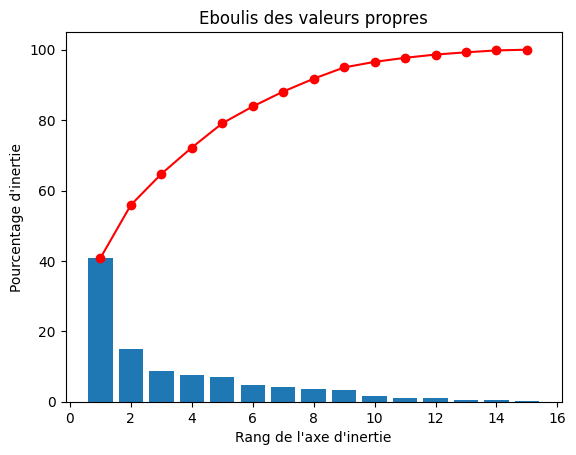

In [9]:
# Eboulis des valeurs propres
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum, c="red", marker="o")
plt.xlabel("Rang de l'axe d'inertie")
plt.ylabel("Pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

L'éboulis des valeurs propres confirme visuellement la réduction de 15 variables à 5 composantes. En effet, selon le critère du coude, on observe une légère rupture visuelle entre F5 et F6 justifiant la sélection de 5. De plus, on peut également voir que le pourcentage d'inertie atteint 80% au niveau de F5

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.2 - ACP réduite (5)</h3>
</div>

In [10]:
# ACP avec seulement 5 composantes
n_components = 5
pca5 = PCA(n_components=n_components)
pca5.fit(df_acp)
print(f"Nombre de composantes: {n_components}")
print(f"Variance totale expliquée: {pca5.explained_variance_ratio_.sum()*100:.2f} %")

Nombre de composantes: 5
Variance totale expliquée: 79.09 %


In [11]:
# Vérification que 79% de la variance provienne de 5 composantes
n1 = pca5.explained_variance_ratio_.sum().round(2)
xpca = PCA(n1)
xpca = xpca.fit_transform(df_acp)
xpca.shape

(164, 5)

Sur 164 pays nous avons réussi à réduire 15 variables à 5 composantes principales

In [12]:
# Coordonnées des variables sur les composantes
coords = pca5.components_.T * np.sqrt(pca5.explained_variance_)

In [13]:
# Tableau des coordonnées
df_coords = pd.DataFrame(
    coords, columns=[f"F{i+1}" for i in range(n_components)], index=df_acp.columns
)
df_coords.round(2)

,F1,F2,F3,F4,F5
CC,0.91,-0.18,-0.09,0.00,0.17
PV,0.78,-0.45,-0.19,-0.03,0.04
Internet,0.87,0.01,0.14,0.01,-0.07
Chomage,-0.01,-0.29,0.70,0.06,-0.39
Evolution tourisme,-0.06,0.00,-0.41,0.77,-0.22
LPI,0.88,0.26,-0.06,0.03,0.17
Distance capitale,-0.24,-0.07,-0.61,-0.52,-0.37
RL,0.93,-0.17,-0.08,-0.00,0.20
RQ,0.94,-0.02,-0.07,0.03,0.17
Evolution population,-0.58,-0.00,-0.17,-0.19,0.53


<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">2.3 - Cercles des corrélations</h3>
</div>

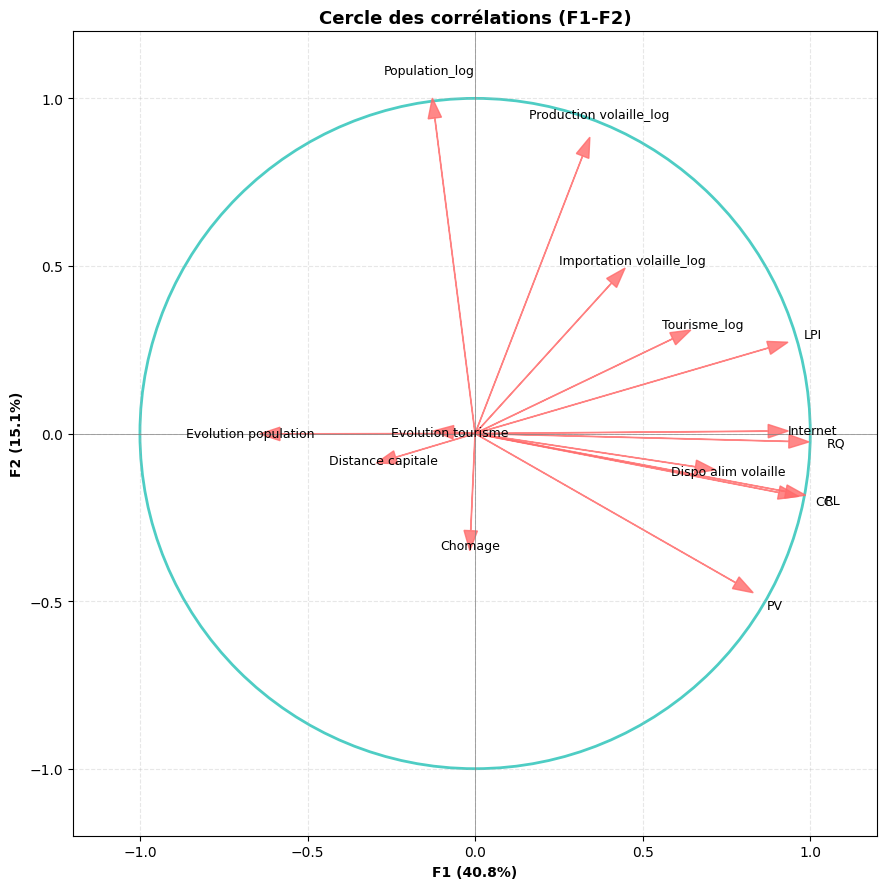

In [14]:
# Visualisation sur un cercle des corrélations de F1 et F2
fig, ax = plt.subplots(figsize=(9, 9))

circle = plt.Circle((0, 0), 1, color="#4ECDC4", fill=False, linewidth=2)
ax.add_artist(circle)

for i, var in enumerate(df_acp.columns):
    x, y = coords[i, 0], coords[i, 1]
    ax.arrow(0, 0, x, y, head_width=0.04, color="#FF6B6B", alpha=0.8)
    ax.text(x * 1.15, y * 1.15, var, fontsize=9, ha="center", va="center")


ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")

# Labels
ax.set_xlabel(f"F1 ({pca5.explained_variance_ratio_[0]*100:.1f}%)", fontweight="bold")
ax.set_ylabel(f"F2 ({pca5.explained_variance_ratio_[1]*100:.1f}%)", fontweight="bold")
ax.set_title("Cercle des corrélations (F1-F2)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

Le cercle des corrélations F1-F2 capte à lui seul 55,9% de la variance totale. Il révèle la structure des deux premières composantes: 
 - Du côté positif, F1 (40,8%) est porté par un groupe de variables fortement corrélées pointant vers la droite touchant presque le cercle. Il y contient les indices de gouvernance (CC, RL, RQ,PV), l'indice de performance logistique LPI, l'accès à internet, la dispo alimentaire en volaille et le nombre de touristes. Aucun coéfficient ne descend en dessous de 0,59. 
 - Du côté négatif de F1, nous avons l'évolution de la population (-0,58) caractérise les pays en croissance démographique, généralement les pays en développement. 
 L'axe F1 représente donc un axe de développement institutionnel et infrastructurel qui oppose les économies développées au pays en développement à démographie dynamique.
 - F2 (15,1%) est dominé par l'importation(0,45), la production de volaille(0,83) et la population(0,94) en positif. Du côté négatif, il y a l'indice de stabilité politique (-0,45).
 F2 représente le poids démographique mis en face de la stabilité politique d'un pays. Les petits pays stables vs les pays géants moins stables.
 Les variables proches du centre ou très mal représentées apporteront surement des informations supplémentaires lors du prochain plan.

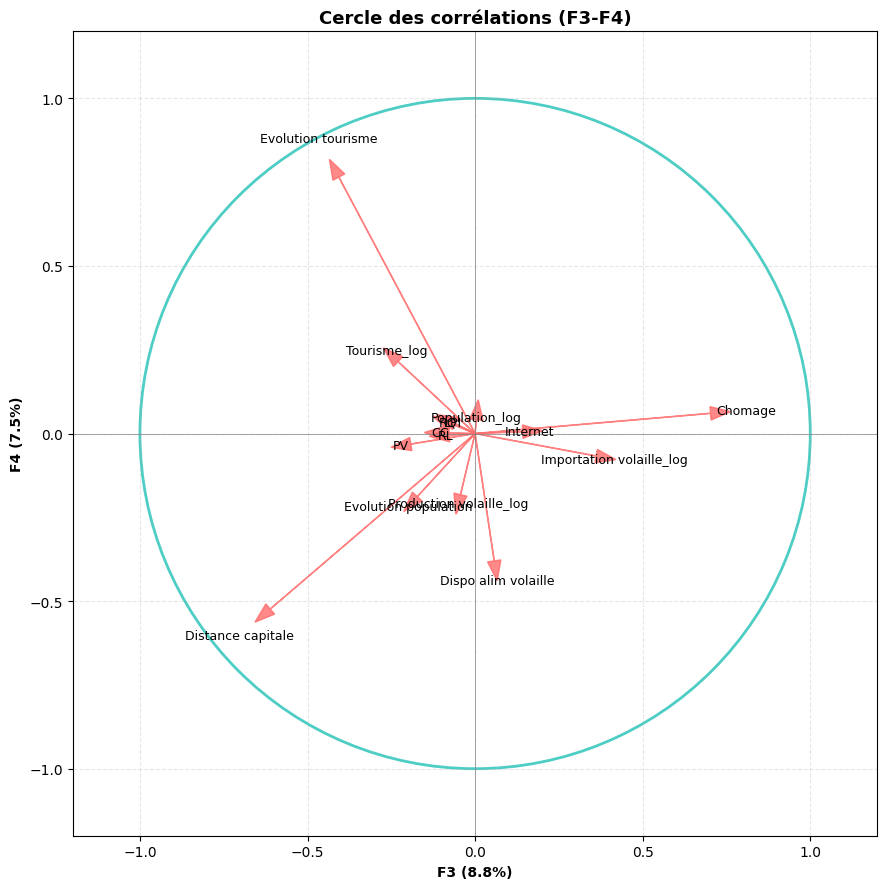

In [15]:
# Visualisation sur un cercle des corrélations de F3 et F4
fig, ax = plt.subplots(figsize=(9, 9))

circle = plt.Circle((0, 0), 1, color="#4ECDC4", fill=False, linewidth=2)
ax.add_artist(circle)

for i, var in enumerate(df_acp.columns):
    x, y = coords[i, 2], coords[i, 3]
    ax.arrow(0, 0, x, y, head_width=0.04, color="#FF6B6B", alpha=0.8)
    ax.text(x * 1.15, y * 1.15, var, fontsize=9, ha="center", va="center")


ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")


ax.set_xlabel(f"F3 ({pca5.explained_variance_ratio_[2]*100:.1f}%)", fontweight="bold")
ax.set_ylabel(f"F4 ({pca5.explained_variance_ratio_[3]*100:.1f}%)", fontweight="bold")
ax.set_title("Cercle des corrélations (F3-F4)", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

Le plan F3-F4 qui capte 16,3% de la variance supplémentaire vient compléter notre lecture en révèlant 3 variables clés qui étaient mal représentées par F1-F2:
 - Du côté positif sur F3(8,8%), nous avons le chômage(0,70) et côté négatif Evolution du tourisme (-0,41) et distance capitale (-0,61)
 F3 distingue les pays proches géographiquement de la France avec un fort taux de chômage des pays plus lointains au tourisme dynamique
 - Une variable positive pour F4(7,5%), Evolution du tourisme (0,77) et une négative distance capitale(-0,52)
 F4 est un axe synthétique qui combine 2 informations indépendantes, la croissance touristique et la proximité géographique. Il distingue donc les pays qui ont simultanément un tourisme en croissance et sont proches de la France et inversement. En revanche, F4 ne traduit aucune relation directe entre les deux variables(cf matrice de corrélation), il capture en réalité une combinaison spécifique de ces 2 dimensions. 

F5(6,89%) est notre dernière composante et capte principalement l'évolution démographique (0,52 sur le tableau des coordonnées).F5 isole donc un signal démographique pur et indépendant du niveau de développement. Cette dimension reste mineure et ne nécessite pas de visualisation dédiée.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 3 - Projection des individus</h2>
</div>

In [16]:
# Projection des pays dans le nouvel espace ACP
X_proj = pca5.transform(df_acp)

# DataFrame avec les coordonnées des pays
df_proj = pd.DataFrame(
    X_proj, columns=[f"F{i+1}" for i in range(n_components)], index=df_acp.index
)

df_proj.head()

,F1,F2,F3,F4,F5
Name,,,,,
Afghanistan,-5.448724,0.462671,1.870175,-0.824656,1.128984
Albania,0.148558,-0.953464,0.889789,2.361691,-1.092663
Algeria,-2.052213,0.724609,0.942361,0.688602,-0.129918
Angola,-3.159405,0.526790,1.769997,-0.767747,0.163075
Argentina,0.602953,1.007362,-0.750133,-1.326580,-1.640049


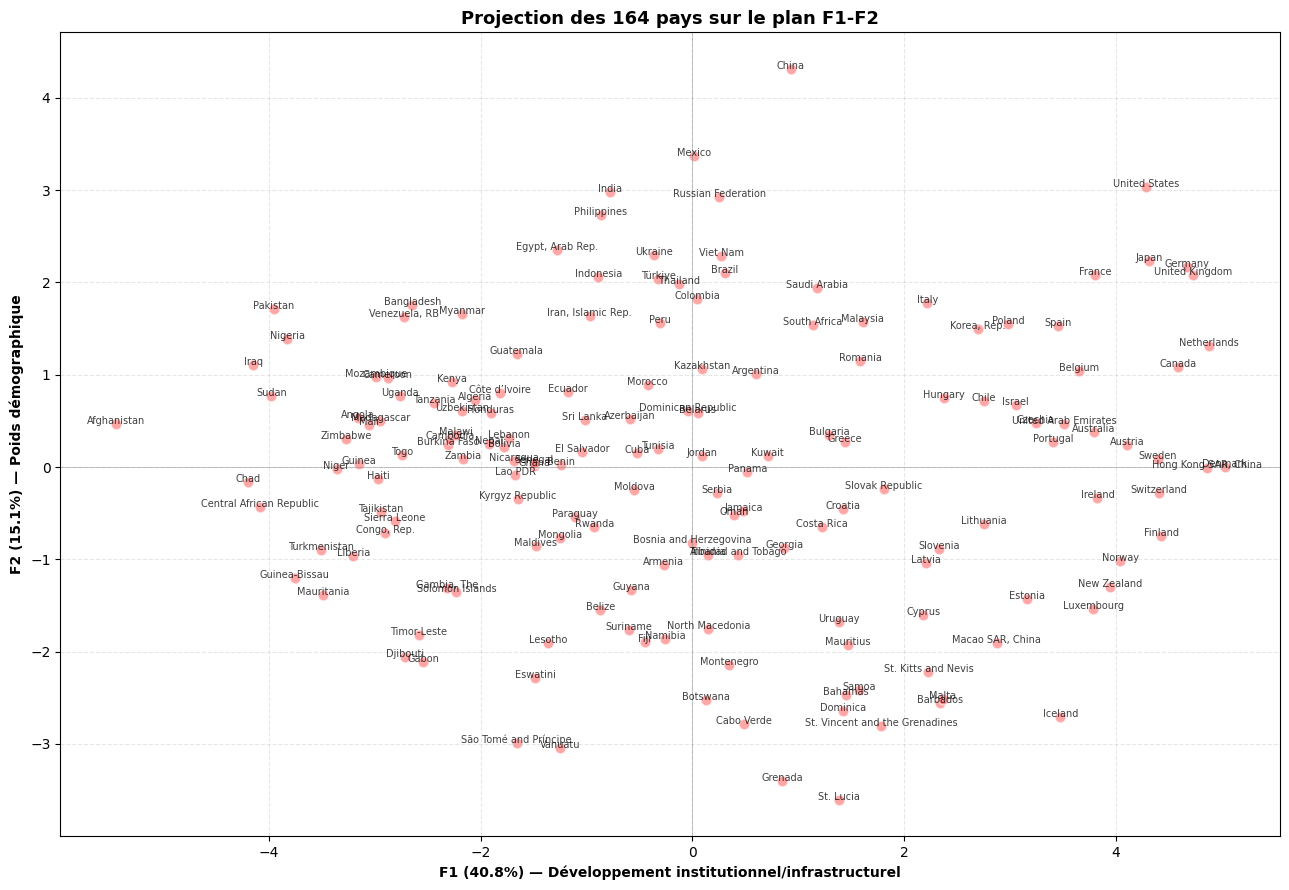

In [17]:
# Nuage de point sur F1-F2
fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(
    df_proj["F1"],
    df_proj["F2"],
    alpha=0.6,
    color="#FF6B6B",
    s=60,
    edgecolors="white",
    linewidth=1,
)

for pays in df_proj.index:
    ax.annotate(
        pays,
        (df_proj.loc[pays, "F1"], df_proj.loc[pays, "F2"]),
        fontsize=7,
        alpha=0.75,
        ha="center",
    )

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.6)

ax.set_xlabel(
    f"F1 ({pca5.explained_variance_ratio_[0]*100:.1f}%) — Développement institutionnel/infrastructurel",
    fontweight="bold",
)
ax.set_ylabel(
    f"F2 ({pca5.explained_variance_ratio_[1]*100:.1f}%) — Poids démographique",
    fontweight="bold",
)
ax.set_title(
    "Projection des 164 pays sur le plan F1-F2", fontsize=13, fontweight="bold"
)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

La projection des 164 pays sur le plan F1-F2(55,9%) révèle plusieurs regroupements naturels:
 - F1+, F2+: les grandes économies développées, USA, France, Japon, Germany, Canada etc...
 - F1-, F2+: les géants démographiques en développement, Inde, Indonésie, Bangladesh, Nigeria, Egypte etc ...
 - F1+, F2-: les petits pays très développés (grande majorité de ces pays sont des îles), Suisse, Finlande, Norvège, Macao, Luxembourg etc...
 - F1-, F2-: les petits pays très vulnérables, peu démographiques et peu développés, Tchad,Libéria, Guinée-Bissau, Gabon etc...

La Chine se démarque très haut sur F2 en raison de sa population colossale. L'Afghanistan est isolé sur la gauche s'illustrant comme le pays le moins développé selon nos indicateurs.

Cette répartition révèle déjà 4 groupes de pays, le plan F3-F4 viendra compléter notre lecture

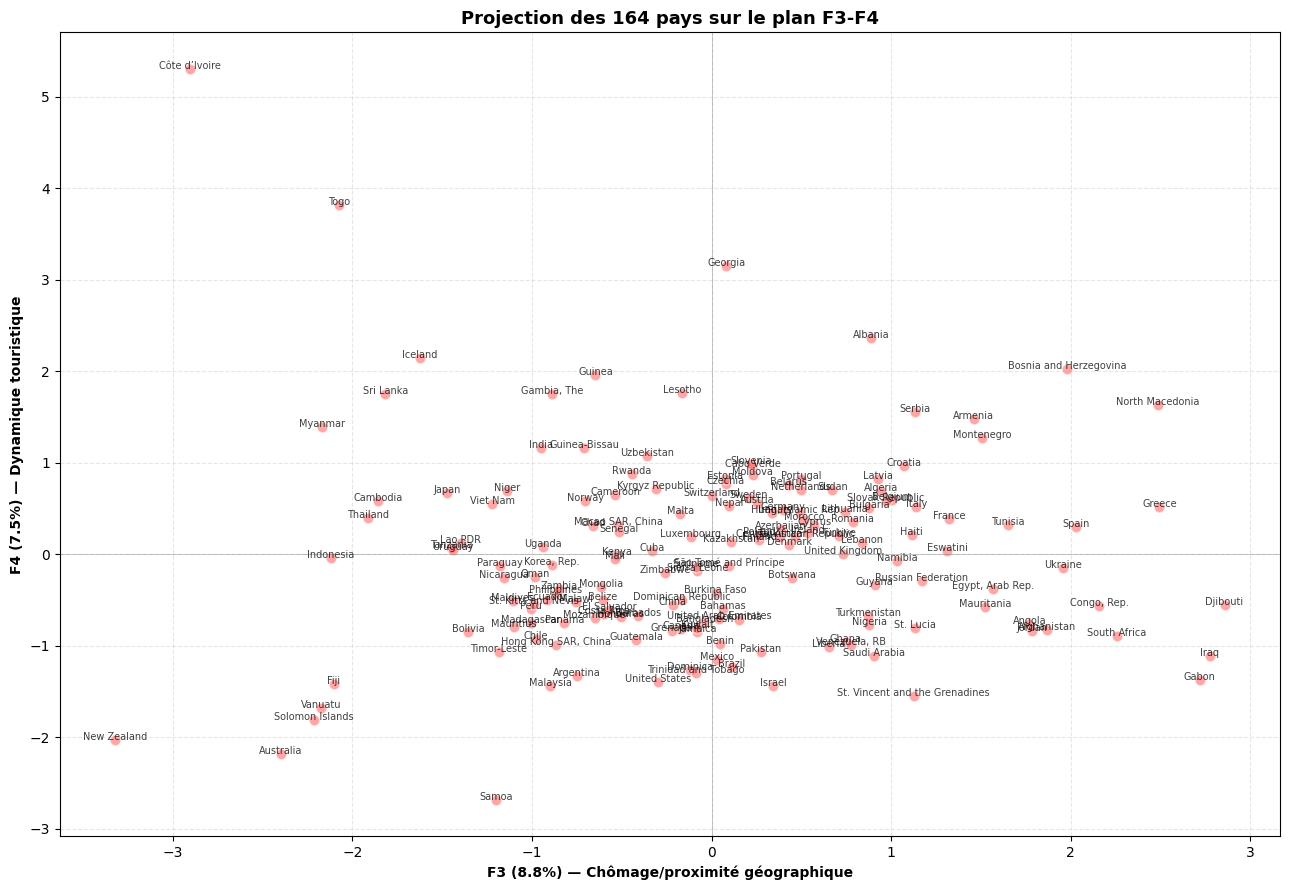

In [18]:
# Nuage de point sur F3-F4
fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(
    df_proj["F3"],
    df_proj["F4"],
    alpha=0.6,
    color="#FF6B6B",
    s=60,
    edgecolors="white",
    linewidth=1,
)

for pays in df_proj.index:
    ax.annotate(
        pays,
        (df_proj.loc[pays, "F3"], df_proj.loc[pays, "F4"]),
        fontsize=7,
        alpha=0.75,
        ha="center",
    )

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.6)

ax.set_xlabel(
    f"F3 ({pca5.explained_variance_ratio_[2]*100:.1f}%) — Chômage/proximité géographique",
    fontweight="bold",
)
ax.set_ylabel(
    f"F4 ({pca5.explained_variance_ratio_[3]*100:.1f}%) — Dynamique touristique",
    fontweight="bold",
)
ax.set_title(
    "Projection des 164 pays sur le plan F3-F4", fontsize=13, fontweight="bold"
)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

Le second plan factoriel F3-F4 capture des informations plus spécifiques et nuancées (~16% de l'information totale). Il agit comme une loupe sur des dynamiques qui n'étaient pas visibles sur le premier plan:
 - L'axe F3 regroupe les pays selon des dynamiques de marché du travail ou des blocs géographiques. En effet, il isole en bas à gauche les pays d'Océanie (Australie, Vanuatu, Nouvelle-Zélande), à droite les pays avec beaucoup de chômage ou éloignés (Djibouti, Gabon, Afrique du Sud)
 - L'axe F4 capte la dynamique touristique avec en haut et l'attractivité des pays. En haut, les pays à forte croissance touristique récente (Albanie, Géorgie). En bas, les pays avec un tourisme plus mature et moins en expansion (USA, Argentine, Malaisie)
 - Ce plan met également en lumière des outliers comme la Côte d'Ivoire, le Togo, les Samoa qui se détachent des autres pays avec des profils touristiques très distincts.

L'analyse en Composantes Principales a réduit nos 15 variables à 5 composantes principales conservant ainsi 79,1% de l'information initiale. Les cercles de corrélations et les projections des pays révèlent des regroupements naturels qui justifient pleinement une approche par clustering.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 4 - Clustering</h2>
</div>

Après avoir réduit la dimensionnalité via l'ACP, nous allons regrouper les pays en clusters homogènes. Nous procèderons en deux temps: une Classification Ascendante Hiérarchique (CAH) pour déterminer le nombre optimal de groupe via le dendrogramme, puis un K-means pour affiner et stabiliser ces groupes. Le clustering est réalisé sur les 5 composantes principales qui résument 79,1% de l'information totale.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.1 - Classification Ascendante Hiérarchique (CAH)</h3>
</div>

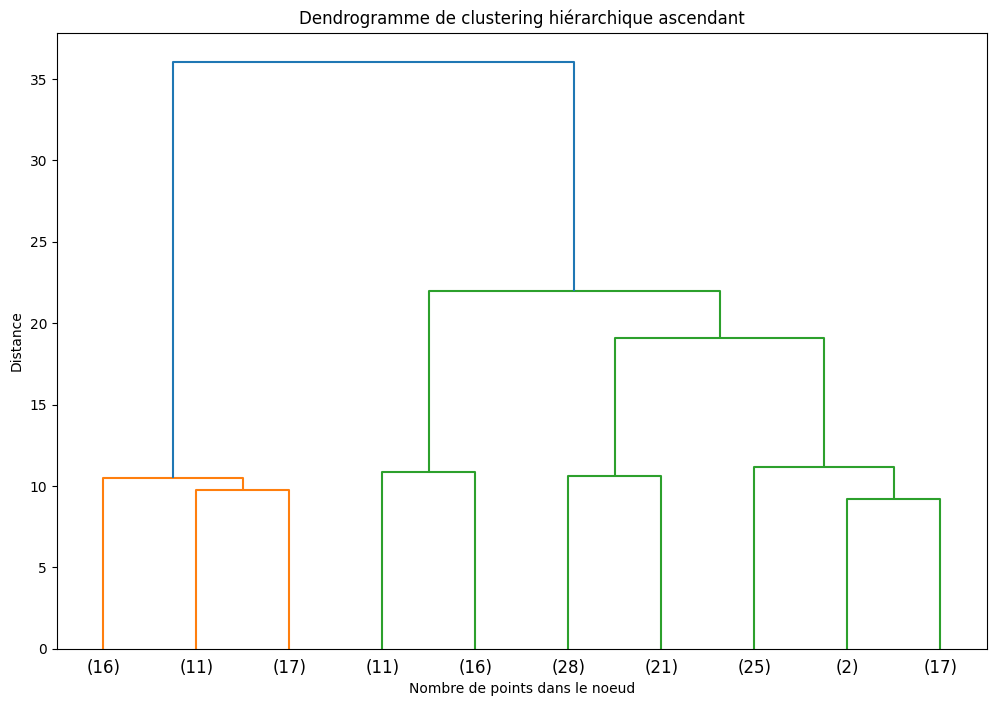

In [19]:
# Dendrogramme
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
Z = linkage(df_proj, method="ward")
_ = dendrogram(Z, p=10, truncate_mode="lastp", ax=ax)
plt.title("Dendrogramme de clustering hiérarchique ascendant")
plt.xlabel("Nombre de points dans le noeud")
plt.ylabel("Distance")
plt.show()

Le dendrogramme tronqué présente les 10 derniers regroupements afin de faciliter la lecture. On observe le plus grand saut de distance entre 22 et 36 qui isolerait donc deux grands blocs, une segmentation un peu trop grossière. Nous couperons donc à 15, nous permettant d'obtenir 4 clusters exploitables que nous confirmerons par la suite avec la méthode du coude et le score de silhouette.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.2 - Méthode du coude</h3>
</div>

In [20]:
# Test de plusieurs valeurs de K
inerties = []
silhouettes = []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(df_proj)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(df_proj, lab))

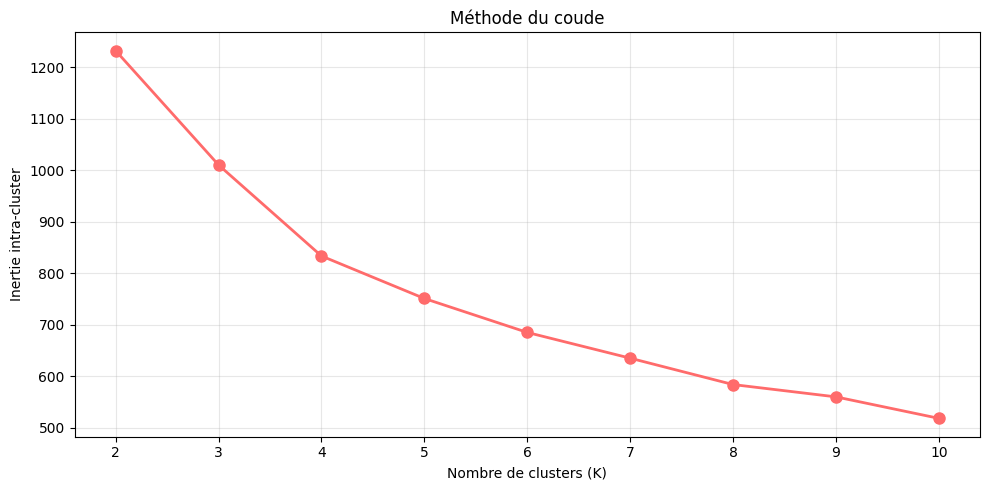

In [21]:
# Graphique du coude
plt.figure(figsize=(10, 5))
plt.plot(ks, inerties, "o-", color="#FF6B6B", linewidth=2, markersize=8)
plt.title("Méthode du coude")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie intra-cluster")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La méthode du coude consiste à observer l'évolution de l'inertie intra-cluster en fonction de leur nombre. On cherche le coude de la courbe, c'est à dire le point à partir duquel ajouter un cluster supplémentaire n'apporte plus qu'un gain marginal. Le graphique nous montre une cassure autour de K=3-4. Au-delà de cette limite, le gain d'inertie devient trop marginal.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.3 - Score de silhouette</h3>
</div>

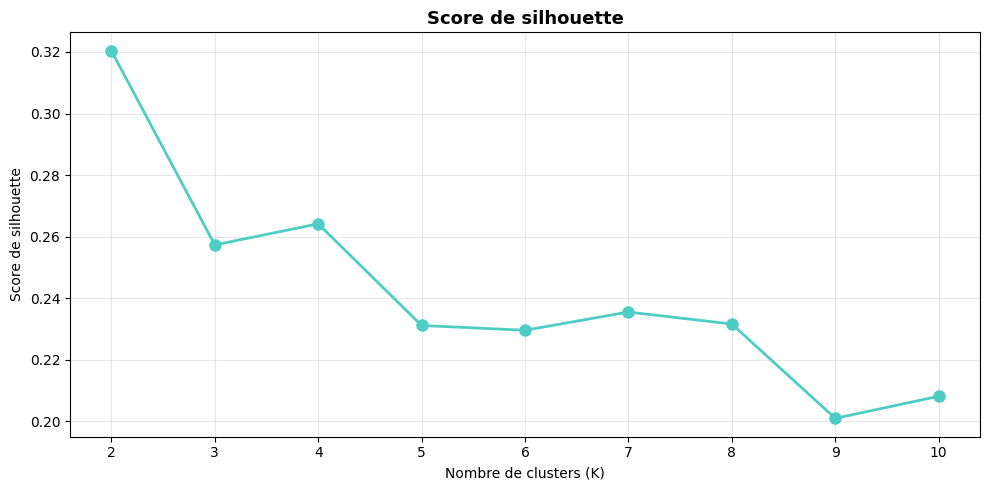

In [22]:
# Score de silhouette
plt.figure(figsize=(10, 5))
plt.plot(ks, silhouettes, "o-", color="#4ECDC4", linewidth=2, markersize=8)
plt.title("Score de silhouette", fontsize=13, fontweight="bold")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Score de silhouette")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Le score de silhouette mesure la qualité de la séparation des clusters, en d'autres termes, il évalue à quel point chaque pays est proche de son propre cluster par rapport aux clusters voisins. Plus le score est élevé et se rapproche de 1, meilleure est la répartition. Dans notre cas, le score le plus élevé est 0,32 soit K=2 mais comme nous l'avons dit précédemment lors du CAH, une segmentation en seulement deux groupes serait trop grossière et inexploitable. Le second pic (~0,26) nous donne K=4 ce qui rejoint donc les conclusions de la méthode du coude et du dendrogramme. 

Nos trois approches convergent vers K=4 et nous pouvons maintenant appliquer l'algorithme du K-means avec ce nombre de clusters afin d'obtenir une partition stable de nos 164 pays

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.4 - K-means</h3>
</div>

In [23]:
# Liste des composantes ACP
compo_acp = ["F1", "F2", "F3", "F4", "F5"]

In [24]:
# K-means avec 4 clusters
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans4.fit(df_proj[compo_acp])
labels4 = kmeans4.labels_

In [25]:
# Stockage des centroids dans une variable
centroids = kmeans4.cluster_centers_

In [26]:
# Ajout du cluster à chaque pays
df_volaille_final["cluster_4"] = labels4
df_proj["cluster_4"] = labels4
print("Répartition des pays par cluster:")
print(df_volaille_final["cluster_4"].value_counts().sort_index())

Répartition des pays par cluster:
cluster_4
0    38
1    35
2    35
3    56
Name: count, dtype: int64


In [27]:
# K-means avec 5 clusters (analyse de robustesse)
kmeans5 = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans5.fit(df_proj[compo_acp])
labels5 = kmeans5.labels_
df_volaille_final["cluster_5"] = labels5
print(df_volaille_final["cluster_5"].value_counts().sort_index())

cluster_5
0    33
1    39
2    34
3    35
4    23
Name: count, dtype: int64


Le paramètre random_state=42 fixe la graine aléatoire afin de garantir la reproductibilité des résultats. Le paramètre n_init=10 relance quant à lui l'algorithme 10 fois avec des initialisations différentes et conserve uniquement la meilleure partition, la partition qui minimise le plus l'inertie intra-cluster garantissant ainsi la robustesse du clustering.

In [28]:
# Tableau de contingence 4 et 5 clusters
comparaison = pd.crosstab(
    df_volaille_final["cluster_4"], df_volaille_final["cluster_5"]
)
comparaison

cluster_5,0,1,2,3,4
cluster_4,,,,,
0,32,5,0,0,1
1,0,0,0,35,0
2,1,0,34,0,0
3,0,34,0,0,22


Après l'étude de la matrice de contingence croisant les résultats pour k=4 et k=5, la décision de poursuivre avec 4 clusters est finale. En effet, les structures des clusters 0, 1 et 2 s'avèrent comme étant extrêmement stables avec la quasi totalité des pays de ces clusters qui conservent leur appartenance respectives. Cela confirme la robustesse de ces groupes. La segmentation en 5 divise simplement le cluster 3 (k=4) en deux groupes n'apportant aucune réelle information utile en plus.

In [29]:
# Variables PESTEL
var_acp_brutes = [
    "CC",
    "PV",
    "Internet",
    "Chomage",
    "Evolution tourisme",
    "LPI",
    "Distance capitale",
    "RL",
    "RQ",
    "Evolution population",
    "Dispo alim volaille",
    "Tourisme",
    "Population",
    "Production volaille",
    "Importation volaille",
]

Pour faciliter l'interprétation business des clusters, nous utiliserons les variables dans leur forme brute, avant toutes les transformations qu'elles ont pu subir.

In [30]:
# Profil moyen de chaque cluster sur les variables d'origine
profil = df_volaille_final.groupby("cluster_4")[var_acp_brutes].mean().round(2)
profil

,CC,PV,Internet,Chomage,Evolution tourisme,LPI,Distance capitale,RL,RQ,Evolution population,Dispo alim volaille,Tourisme,Population,Production volaille,Importation volaille
cluster_4,,,,,,,,,,,,,,,
0,39.18,58.30,59.57,7.12,69.09,2.88,6294.26,49.28,52.47,4.18,8.04,16810342.11,121378.03,1894.95,135.03
1,53.30,73.68,59.43,11.82,77.62,2.72,6567.17,61.39,57.71,2.35,9.55,3600045.71,1693.64,38.81,17.76
2,75.04,79.38,86.26,5.82,55.57,3.70,3537.17,79.66,76.85,2.22,10.91,35133021.43,31243.58,1242.39,213.39
3,30.24,54.30,27.14,6.28,72.20,2.48,6300.62,42.76,43.82,10.37,2.39,1084555.36,25348.42,93.48,37.45


In [31]:
# Liste des pays par cluster
for k in range(4):
    pays = df_volaille_final[df_volaille_final["cluster_4"] == k]["Name"].tolist()
    print(f"\n=== Cluster {k} ({len(pays)} pays) ===")
    print(", ".join(pays))


=== Cluster 0 (38 pays) ===
Argentina, Azerbaijan, Belarus, Brazil, Bulgaria, China, Colombia, Cuba, Dominican Republic, Ecuador, Egypt, Arab Rep., El Salvador, Greece, India, Indonesia, Iran, Islamic Rep., Jordan, Kazakhstan, Kuwait, Malaysia, Mexico, Moldova, Morocco, Myanmar, Panama, Peru, Philippines, Romania, Russian Federation, Saudi Arabia, South Africa, Sri Lanka, Thailand, Tunisia, Türkiye, Ukraine, Venezuela, RB, Viet Nam

=== Cluster 1 (35 pays) ===
Albania, Armenia, Bahamas, Barbados, Belize, Bosnia and Herzegovina, Botswana, Cabo Verde, Costa Rica, Croatia, Cyprus, Dominica, Eswatini, Fiji, Georgia, Grenada, Guyana, Jamaica, Latvia, Lesotho, Malta, Mauritius, Montenegro, Namibia, North Macedonia, Samoa, São Tomé and Príncipe, Serbia, St. Kitts and Nevis, St. Lucia, St. Vincent and the Grenadines, Suriname, Trinidad and Tobago, Uruguay, Vanuatu

=== Cluster 2 (35 pays) ===
Australia, Austria, Belgium, Canada, Chile, Czechia, Denmark, Estonia, Finland, France, Germany, Hong

 - Cluster 0 - Grandes économies émergentes (38 pays), Chine, Colombie, Brésil, Égypte, Inde. Des pays très peuplés en développement rapide et avec une production de volaille déjà conséquente.
  - Cluster 1 - Petits pays à revenu intermédiaire (35 pays), beaucoup sont des états insulaires donc plus difficiles et coûteux à atteindre. Économie modeste principalement découlant du tourisme.
  - Cluster 2 - (35 pays) Les pays développés, France, USA, Allemagne, Belgique, Italie, plus gros importateurs de volaille, 2ème plus gros producteur de volaille, la plus conséquente disponibilité alimentaire en volaille par habitant, les meilleurs indices de gouvernance, le plus développé en termes d'infrastructure, de technologie et de logistique. Enfin, ce cluster cumule le plus de tourisme des 3 autres clusters confirmant ainsi son potentiel et il est le plus proches de France. Cumulant le meilleur score pour 12 des 15 variables initiales, il s'impose comme la cible d'export principale.
  - Cluster 3 - (56 pays), le plus gros cluster. Les pays en développement à forte croissance démographique, la majorité des pays sont sur le continent africain/Moyen-orient. La plus faible disponibilité alimentaire en volaille par habitant des clusters et quasiment le pire en production et importation de volaille.

<div style="border: 1px solid #4ECDC4;" >
<h3 style="margin: auto; padding: 20px; color: #4ECDC4; ">4.5 - Visualisation des clusters</h3>
</div>

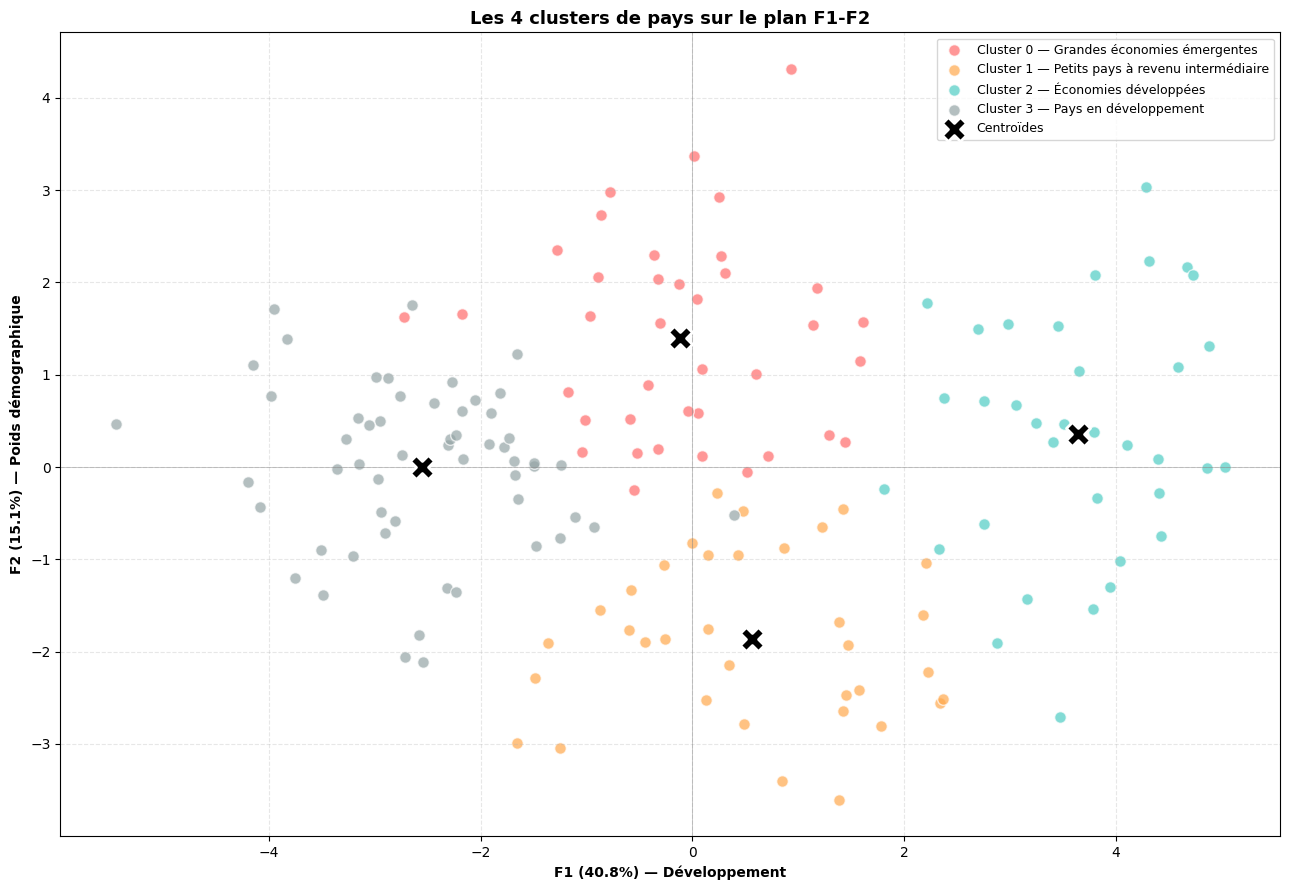

In [32]:
# Visualisation des clusters sur plan F1 et F2
fig, ax = plt.subplots(figsize=(13, 9))

cluster_names = {
    0: "Grandes économies émergentes",
    1: "Petits pays à revenu intermédiaire",
    2: "Économies développées",
    3: "Pays en développement",
}
colors = ["#FF6B6B", "#FFA94D", "#4ECDC4", "#95A5A6"]

for k in range(4):
    mask = df_proj["cluster_4"] == k
    ax.scatter(
        df_proj.loc[mask, "F1"],
        df_proj.loc[mask, "F2"],
        c=colors[k],
        label=f"Cluster {k} — {cluster_names[k]}",
        alpha=0.7,
        s=70,
        edgecolors="white",
        linewidth=1,
    )

ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c="black",
    marker="X",
    s=300,
    edgecolors="white",
    linewidth=2,
    label="Centroïdes",
    zorder=5,
)

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.set_xlabel(
    f"F1 ({pca5.explained_variance_ratio_[0]*100:.1f}%) — Développement",
    fontweight="bold",
)
ax.set_ylabel(
    f"F2 ({pca5.explained_variance_ratio_[1]*100:.1f}%) — Poids démographique",
    fontweight="bold",
)
ax.set_title("Les 4 clusters de pays sur le plan F1-F2", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

La projection des clusters sur le plan F1-F2 confirme la qualité de notre segmentation avec 4 groupes occupant des zones distinctes de l'espace factoriel.
Le cluster 3 se concentre à gauche, du côté des faibles valeurs de F1 signifiant un faible niveau de développement institutionnel et infrastructurel. 
Le cluster 2 se situe nettement sur la droite du plan caractérisant ainsi les pays avec les meilleurs indices de gouvernance, d'infrastructure et d'accès à internet.
Le cluster 0 occupe le haut du graphique représentant les fortes populations aux économies émergentes.
Le cluster 1 se positionne en bas pour les pays à faible population et faible développement.
Les centroïdes (croix noires) matérialisent le centre de gravité de chaque groupe confirmant cette séparation

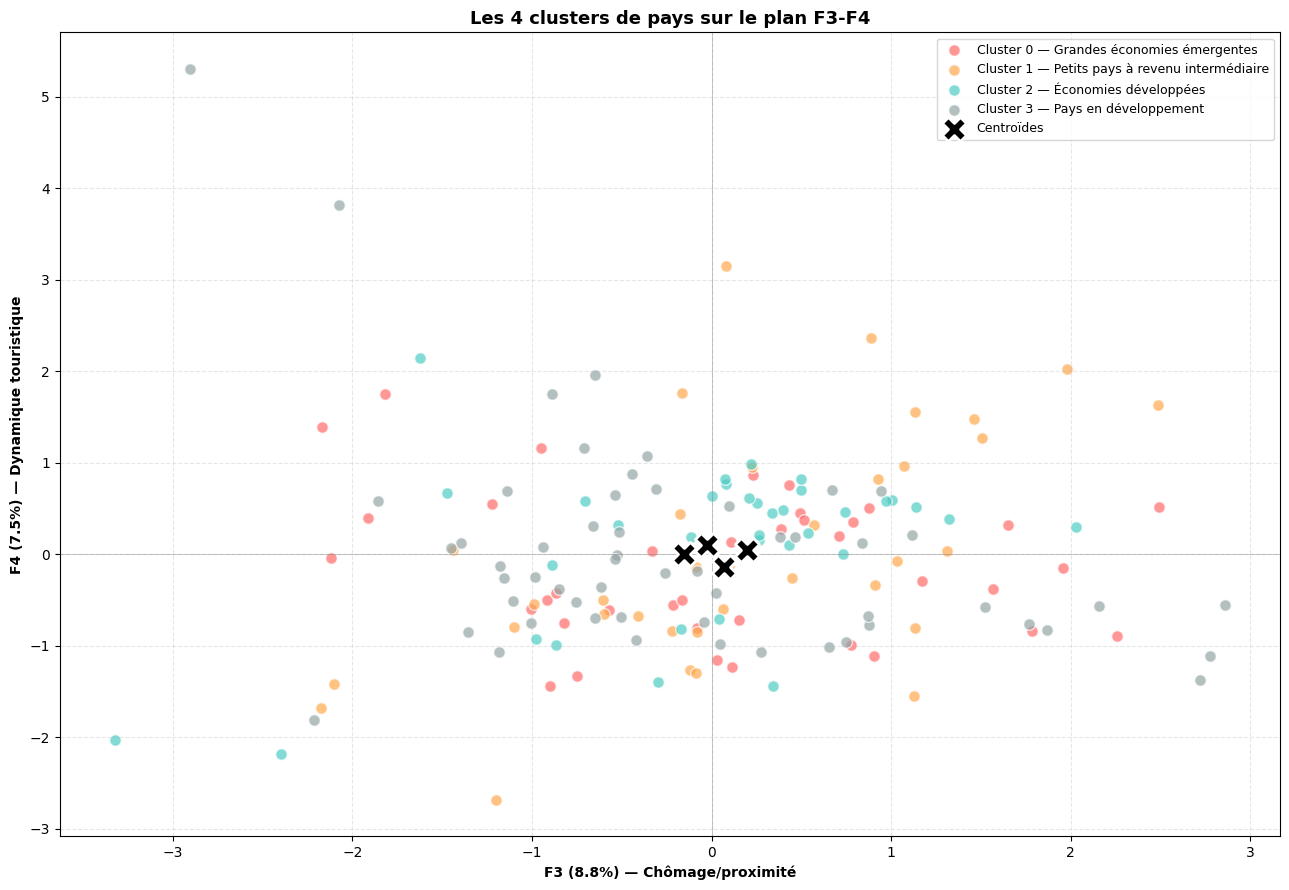

In [33]:
# Visualisation des clusters sur plan F3 et F4
fig, ax = plt.subplots(figsize=(13, 9))

cluster_names = {
    0: "Grandes économies émergentes",
    1: "Petits pays à revenu intermédiaire",
    2: "Économies développées",
    3: "Pays en développement",
}
colors = ["#FF6B6B", "#FFA94D", "#4ECDC4", "#95A5A6"]

for k in range(4):
    mask = df_proj["cluster_4"] == k
    ax.scatter(
        df_proj.loc[mask, "F3"],
        df_proj.loc[mask, "F4"],
        c=colors[k],
        label=f"Cluster {k} — {cluster_names[k]}",
        alpha=0.7,
        s=70,
        edgecolors="white",
        linewidth=1,
    )

ax.scatter(
    centroids[:, 2],
    centroids[:, 3],
    c="black",
    marker="X",
    s=300,
    edgecolors="white",
    linewidth=2,
    label="Centroïdes",
    zorder=5,
)

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.6)
ax.set_xlabel(
    f"F3 ({pca5.explained_variance_ratio_[2]*100:.1f}%) — Chômage/proximité",
    fontweight="bold",
)
ax.set_ylabel(
    f"F4 ({pca5.explained_variance_ratio_[3]*100:.1f}%) — Dynamique touristique",
    fontweight="bold",
)
ax.set_title("Les 4 clusters de pays sur le plan F3-F4", fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

Sur le plan F3-F4, les 4 clusters se chevauchent fortement et leurs centroïdes sont tous concentrés autour de l'origine. Ce résultat était attendu car la séparation des clusters repose essentiellement sur les axes F1-F2, tandis que F3-F4 ne capte que 16% de la variance totale.
Ce plan confirme que nos groupes se distinguent avant tout par leur niveau de développement et leur taille démographique plutôt que par leur dynamique touristique ou leur niveau de chômage.

<div style="background-color: #4ECDC4;" >
<h2 style="margin: auto; padding: 20px; color: white; ">Etape 5 - Représentation géographique des clusters</h2>
</div>

In [ ]:
# Actualisation du nom de la Turquie pour la carte
df_volaille_final["Name"] = df_volaille_final["Name"].replace("Türkiye", "Turkey")

In [35]:
# Carte géographique des clusters
df_carte = df_volaille_final[["Name", "cluster_4"]].copy()

cluster_names = {
    0: "Grandes économies émergentes",
    1: "Petits pays à revenu intermédiaire",
    2: "Économies développées",
    3: "Pays en développement",
}
df_carte["Groupe"] = df_carte["cluster_4"].map(cluster_names)

color_map = {
    "Grandes économies émergentes": "#FF6B6B",
    "Petits pays à revenu intermédiaire": "#FFA94D",
    "Économies développées": "#4ECDC4",
    "Pays en développement": "#95A5A6",
}

fig = px.choropleth(
    df_carte,
    locations="Name",
    locationmode="country names",
    color="Groupe",
    hover_name="Name",
    color_discrete_map=color_map,
    projection="natural earth",
    title="Segmentation mondiale des 164 pays par cluster",
)

fig.update_layout(
    title=dict(
        text="Segmentation mondiale des 164 pays par cluster", x=0.5, font=dict(size=18)
    ),
    width=1400,
    height=800,
    legend=dict(
        title="Clusters",
        orientation="h",
        yanchor="bottom",
        y=-0.1,
        x=0.5,
        xanchor="center",
        font=dict(size=12),
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        showcountries=True,
        countrycolor="lightgray",
        showocean=True,
        oceancolor="#f0f8ff",
        showland=True,
        landcolor="#f5f5f5",
    ),
)

fig.show()

/var/folders/yn/3_wmrcjj4bz_6hz4_nqjgfdw0000gn/T/ipykernel_11962/1057650656.py:19: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


Cette carte choroplèthe nous donne une représentation géographique de nos 164 pays segmentés en 4 clusters. C'est la dernière étape de notre étude de marché car elle nous indique les zones géographiques à cibler.
Les pays à économies développées (turquoise) ont précédemment été identifiés comme la meilleure cible pour exporter de la volaille à l'international. Ils combinent proximité à la France, stabilité politique et facilité logistique ce qui facilite grandement l'ouverture d'export. Ils représentent également de gros marchés démographiques avec les plus haut chiffres de disponibilité alimentaire en volaille par habitant. Ce cluster couvre donc une grande partie de l'Europe, USA/Canada et Australie/Japon. 
L'Europe et l'Amérique du Nord semblent donc les meilleures zones à cibler pour l'exportation de La poule qui chante à l'international.